# Phase 4: Model Implementation - ESM-2 Fine-Tuning (Google Colab)

Notebook ini adalah versi Colab dari `05_esm2_model.ipynb`, dioptimasi untuk **GPU T4 (16GB VRAM)**.

ESM-2 adalah large language model pretrained pada 65 juta sekuens protein. Dengan LoRA fine-tuning, kita mengadaptasi model ini untuk klasifikasi 6 famili protein.

**Data harus diupload ke Google Drive** sebelum menjalankan notebook ini (lihat instruksi di bagian dataset).

In [2]:
# @title 1. Mount Google Drive
# Hasil training akan disimpan di sini
from google.colab import drive
drive.mount('/content/drive')

# Buat folder di Drive untuk project ini (ganti PATH sesuai struktur Drive kamu)
DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/protein-esm2"
!mkdir -p "$DRIVE_BASE/data/processed"
!mkdir -p "$DRIVE_BASE/models"
!mkdir -p "$DRIVE_BASE/results"
print(f"Drive siap. Semua file akan disimpan di: {DRIVE_BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive siap. Semua file akan disimpan di: /content/drive/MyDrive/Colab Notebooks/protein-esm2


In [11]:
# @title 2. Install Dependencies
# Colab sudah punya PyTorch + CUDA, install sisanya
!pip install -q transformers peft scikit-learn matplotlib seaborn pandas

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

warnings.filterwarnings('ignore')

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB



---
##  Dataset

**Upload data berikut ke Google Drive** di folder `protein-esm2/data/processed/`:
- `train.csv`
- `val.csv`
- `test.csv`
- `label_mapping.json`

File-file ini ada di folder `data/processed/` project lokal kamu. Upload via Drive web interface, lalu jalankan cell di bawah.

In [12]:
# @title 3. Load Dataset (dari Google Drive)
DATA_DIR = f"{DRIVE_BASE}/data/processed"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

with open(f"{DATA_DIR}/label_mapping.json", 'r') as f:
    label_mapping = json.load(f)

num_classes = len(label_mapping)
class_names = [label_mapping[str(i)] for i in range(num_classes)]
print(f"Data Train: {len(train_df)}, Data Val: {len(val_df)}, Data Test: {len(test_df)}, Jumlah Kelas: {num_classes}")
print(f"Kelas: {class_names}")

Data Train: 17564, Data Val: 3764, Data Test: 3764, Jumlah Kelas: 6
Kelas: ['GPCR', 'Hydrolase', 'Ion Channel', 'Kinase', 'Oxidoreductase', 'Transcription Factor']


In [13]:
# @title 4. Load ESM-2 Tokenizer
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"EOS token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
print(f"PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")

Vocab size: 33
CLS token: <cls> (ID: 0)
EOS token: <eos> (ID: 2)
PAD token: <pad> (ID: 1)


In [14]:
# @title 5. Definisi Dataset Class
MAX_LEN = 1002  # 1000 (sekuens) + <cls> + <eos>

class ProteinESMDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_len=MAX_LEN):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = str(self.sequences.iloc[idx])
        label = self.labels.iloc[idx]

        encoded = self.tokenizer(
            seq,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [15]:
# @title 6. Buat DataLoader (T4: batch=16 untuk 16GB VRAM)
BATCH_SIZE = 16

train_dataset = ProteinESMDataset(train_df['Sequence'], train_df['Label'], tokenizer)
val_dataset = ProteinESMDataset(val_df['Sequence'], val_df['Label'], tokenizer)
test_dataset = ProteinESMDataset(test_df['Sequence'], test_df['Label'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print("DataLoader siap.")

Train batches: 1098, Val batches: 236, Test batches: 236
DataLoader siap.


In [16]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

warnings.filterwarnings('ignore')

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
# @title 7. Setup Model dengan LoRA + Custom Classification Head
class CustomClassifier(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, seq_len, hidden_size] — ambil <cls> token pertama
        x = x[:, 0, :]
        return self.fc(x)

# Load base model
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)

# Ganti classifier head SEBELUM LoRA
hidden_size = base_model.config.hidden_size
base_model.classifier = CustomClassifier(hidden_size, num_classes)

# Konfigurasi LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["query", "key", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# Upgrade torchao to resolve compatibility issues with peft
!pip install -q "torchao>=0.16.0"

model = get_peft_model(base_model, lora_config)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}% dari total)")

model = model.to(device)
print("Model siap.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB



Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmForSequenceClassification LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 33,795,357
Trainable parameters: 401,158 (1.19% dari total)
Model siap.


In [17]:
# @title 8. Konfigurasi Pelatihan
labels_array = train_df['Label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 50
PATIENCE = 5
ACCUMULATION_STEPS = 2  # Effective batch = 16 * 2 = 32
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False
best_model_path = f"{DRIVE_BASE}/models/esm2_model_best"

print(f"Konfigurasi training siap.")
print(f"  Batch size: {BATCH_SIZE}, Accumulation steps: {ACCUMULATION_STEPS}, Effective batch: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f"  Optimizer: AdamW, LR: 1e-4, Weight Decay: 1e-4")
print(f"  Mixed Precision: FP16")
print(f"  Early Stopping patience: {PATIENCE}, Max epochs: {EPOCHS}")

Konfigurasi training siap.
  Batch size: 16, Accumulation steps: 2, Effective batch: 32
  Optimizer: AdamW, LR: 1e-4, Weight Decay: 1e-4
  Mixed Precision: FP16
  Early Stopping patience: 5, Max epochs: 50


In [18]:
# @title 9. Training Loop
print("\nMemulai proses pelatihan...")
for epoch in range(EPOCHS):
    start_time = time.time()

    # --- FASE TRAINING ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for i, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUMULATION_STEPS * input_ids.size(0)
        _, preds = torch.max(outputs.logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = train_loss / total
    epoch_train_acc = correct / total

    # --- FASE VALIDATION ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
            val_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(outputs.logits, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    elapsed_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Waktu: {elapsed_time:.0f}s | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    # Early Stopping & Checkpoint
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        model.save_pretrained(best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n[Early Stopping Triggered] No improvement for {PATIENCE} consecutive epochs.")
            early_stop_triggered = True
            break

print("\n--- Training Summary ---")
print(f"Early Stopping Triggered: {early_stop_triggered}")
print(f"Total Epochs Run: {epoch + 1}")
print(f"Best Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")

# Load best model weights
base_model_best = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)
base_model_best.classifier = CustomClassifier(base_model_best.config.hidden_size, num_classes)
model = PeftModel.from_pretrained(base_model_best, best_model_path)
model = model.to(device)
model.eval()
print("Best model weights loaded.")


Memulai proses pelatihan...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch 01/50 | Waktu: 1037s | LR: 0.000100 | Train Loss: 0.8176 Acc: 0.7249 | Val Loss: 0.3873 Acc: 0.8804
Epoch 02/50 | Waktu: 1042s | LR: 0.000100 | Train Loss: 0.3110 Acc: 0.9049 | Val Loss: 0.2643 Acc: 0.9195
Epoch 03/50 | Waktu: 1042s | LR: 0.000100 | Train Loss: 0.2182 Acc: 0.9341 | Val Loss: 0.2317 Acc: 0.9299
Epoch 04/50 | Waktu: 1043s | LR: 0.000100 | Train Loss: 0.1754 Acc: 0.9480 | Val Loss: 0.2225 Acc: 0.9315
Epoch 05/50 | Waktu: 1042s | LR: 0.000100 | Train Loss: 0.1436 Acc: 0.9554 | Val Loss: 0.2256 Acc: 0.9304
Epoch 06/50 | Waktu: 1041s | LR: 0.000100 | Train Loss: 0.1199 Acc: 0.9613 | Val Loss: 0.2257 Acc: 0.9386
Epoch 07/50 | Waktu: 1041s | LR: 0.000050 | Train Loss: 0.1083 Acc: 0.9661 | Val Loss: 0.2441 Acc: 0.9301
Epoch 08/50 | Waktu: 1041s | LR: 0.000050 | Train Loss: 0.0802 Acc: 0.9744 | Val Loss: 0.2360 Acc: 0.9408
Epoch 09/50 | Waktu: 1042s | LR: 0.000050 | Train Loss: 0.0730 Acc: 0.9761 | Val Loss: 0.2542 Acc: 0.9376

[Early Stopping Triggered] No improvement for

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmForSequenceClassification LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model weights loaded.



--- Classification Report ---
                      precision    recall  f1-score   support

                GPCR       0.99      0.97      0.98       498
           Hydrolase       0.86      0.89      0.87       643
         Ion Channel       0.95      0.97      0.96       671
              Kinase       0.96      0.92      0.94       628
      Oxidoreductase       0.90      0.95      0.93       679
Transcription Factor       0.94      0.88      0.91       645

            accuracy                           0.93      3764
           macro avg       0.93      0.93      0.93      3764
        weighted avg       0.93      0.93      0.93      3764

Accuracy: 0.9307
F1 Macro: 0.9325
MCC Score: 0.9168


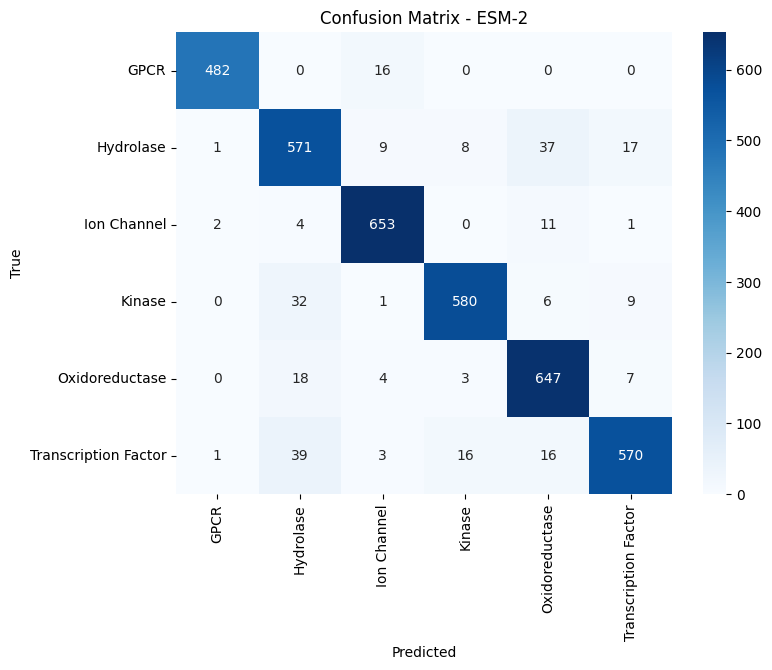

In [20]:
# @title 10. Evaluasi Metrik
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        probs = torch.softmax(outputs.logits, dim=1)
        _, preds = torch.max(outputs.logits, 1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Classification Report ---")
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')
mcc = matthews_corrcoef(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"MCC Score: {mcc:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ESM-2')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

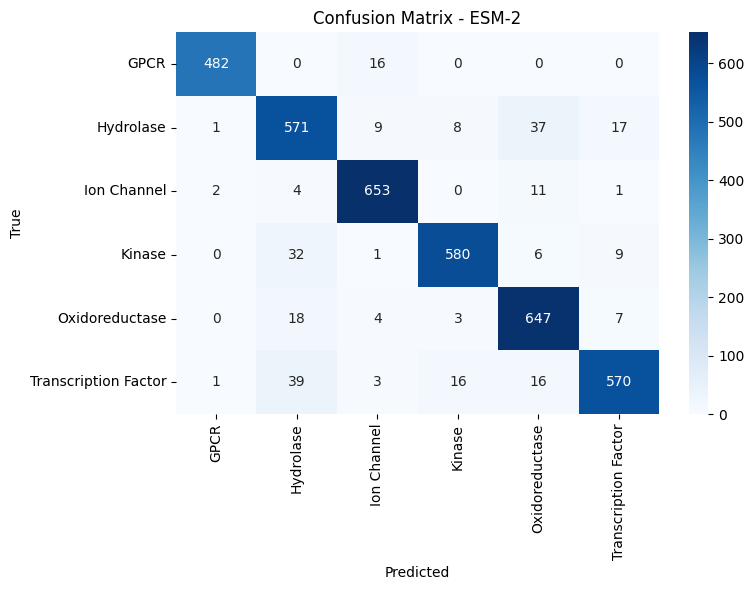

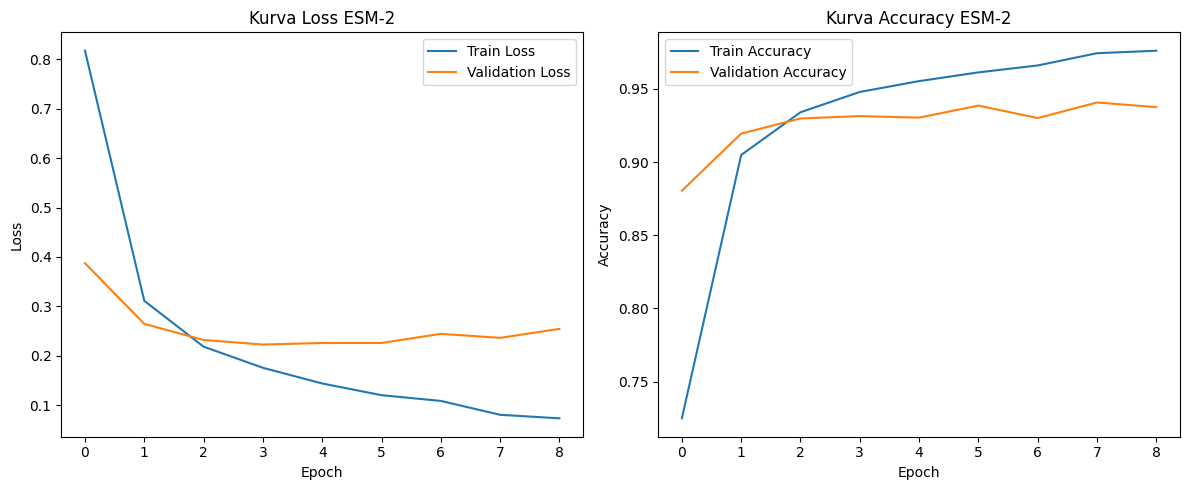

Semua hasil disimpan di: /content/drive/MyDrive/Colab Notebooks/protein-esm2/results/
File:
  - esm2_metrics.json
  - confusion_matrix_esm2.png
  - learning_curves_esm2.png


In [21]:
# @title 11. Simpan Hasil ke Google Drive
results = {
    'accuracy': accuracy,
    'f1_macro': f1_macro,
    'mcc': mcc,
    'history': history
}

# Simpan metrics
with open(f"{DRIVE_BASE}/results/esm2_metrics.json", 'w') as f:
    json.dump(results, f)

# Simpan confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ESM-2')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(f"{DRIVE_BASE}/results/confusion_matrix_esm2.png", dpi=150)
plt.show()

# Simpan history plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss ESM-2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Kurva Accuracy ESM-2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"{DRIVE_BASE}/results/learning_curves_esm2.png", dpi=150)
plt.show()

print(f"Semua hasil disimpan di: {DRIVE_BASE}/results/")
print("File:")
for f in os.listdir(f"{DRIVE_BASE}/results/"):
    print(f"  - {f}")

In [22]:
# @title 12. Download Hasil ke Lokal
# Jalankan ini untuk mendownload hasil training sebagai ZIP
import shutil

zip_path = "/content/esm2_results.zip"
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', f"{DRIVE_BASE}/results")

from google.colab import files
files.download(zip_path)
print("Download selesai setelah file terunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download selesai setelah file terunduh.
